In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Final_data.csv')

In [4]:
df

,ON_STREAM_HRS,AVG_CHOKE_SIZE_P,AVG_WHP_P,DP_CHOKE_SIZE,Total_Injection_VOL,BORE_OIL_VOL
0,11.50,14.48443,106.806,92.475,0.0,285.0
1,24.00,22.83299,120.889,89.620,0.0,1870.0
2,22.50,31.24997,113.718,80.120,0.0,3124.0
3,23.15,28.51893,116.831,84.251,0.0,2608.0
4,24.00,30.22790,115.434,82.359,0.0,3052.0
...,...,...,...,...,...,...
2891,22.83,86.52358,28.450,1.934,7269.0,167.0
2892,24.00,100.00000,26.480,0.472,7938.0,197.0
2893,24.00,100.00000,26.263,0.435,8077.0,223.0
2894,24.00,100.00000,26.451,0.744,8043.0,217.0


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
      dtype=object)

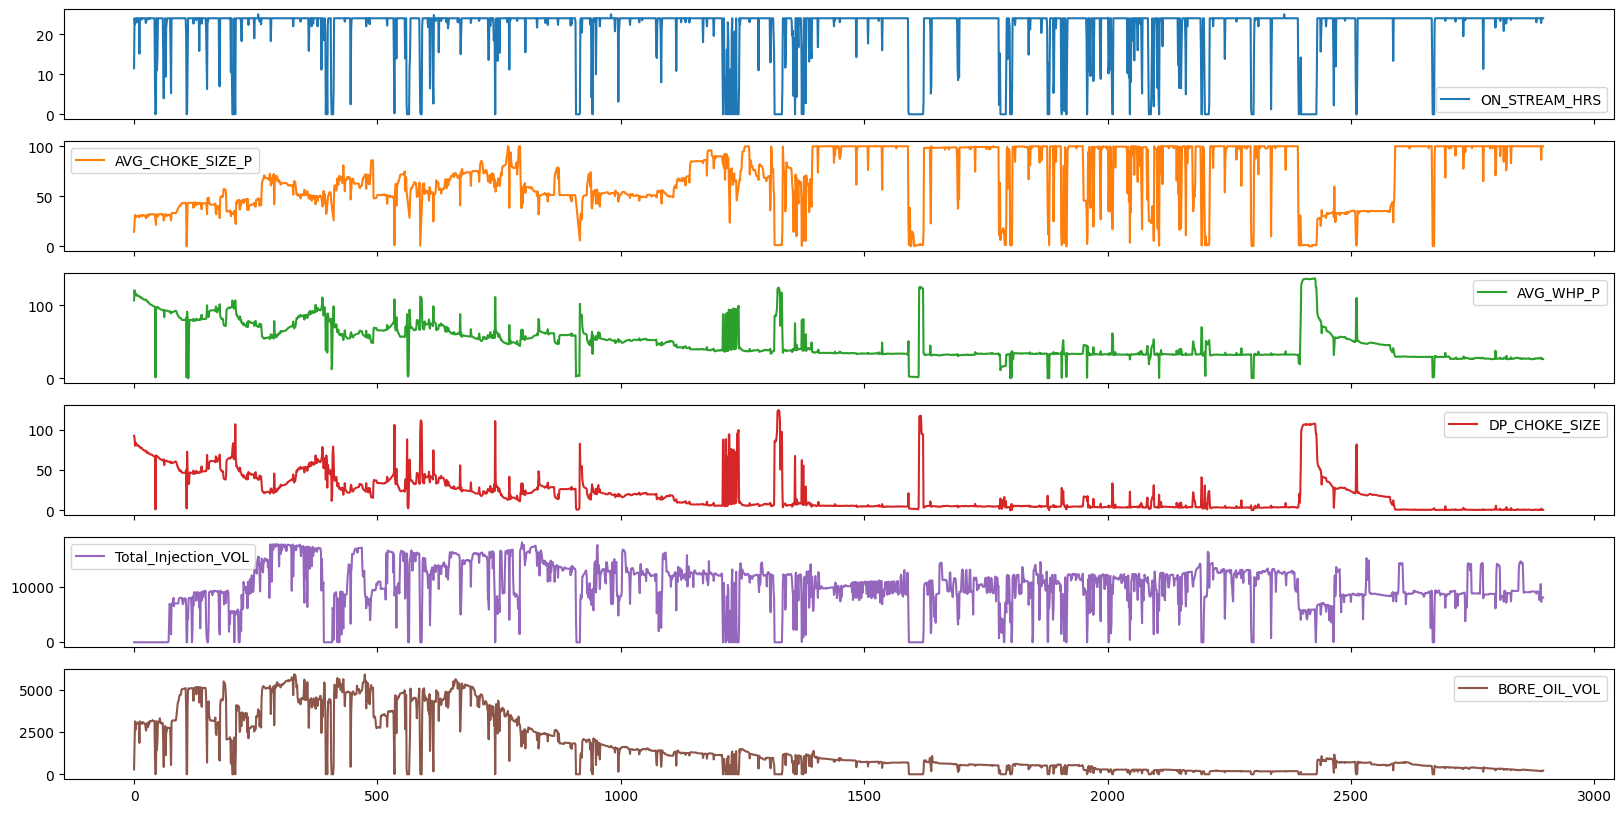

In [5]:
df.plot(subplots=True, figsize=(20,10))

In [6]:
from sklearn.model_selection import train_test_split


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [8]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler


In [29]:
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
        },
        index=[0],
    )

    return df_perf

In [10]:
df

,ON_STREAM_HRS,AVG_CHOKE_SIZE_P,AVG_WHP_P,DP_CHOKE_SIZE,Total_Injection_VOL,BORE_OIL_VOL
0,11.50,14.48443,106.806,92.475,0.0,285.0
1,24.00,22.83299,120.889,89.620,0.0,1870.0
2,22.50,31.24997,113.718,80.120,0.0,3124.0
3,23.15,28.51893,116.831,84.251,0.0,2608.0
4,24.00,30.22790,115.434,82.359,0.0,3052.0
...,...,...,...,...,...,...
2891,22.83,86.52358,28.450,1.934,7269.0,167.0
2892,24.00,100.00000,26.480,0.472,7938.0,197.0
2893,24.00,100.00000,26.263,0.435,8077.0,223.0
2894,24.00,100.00000,26.451,0.744,8043.0,217.0


In [11]:
scaler = MinMaxScaler()

In [12]:
df_scaled = scaler.fit_transform(df)

In [13]:
df_scaled

array([[0.46      , 0.1448443 , 0.77784009, 0.74490791, 0.        ,
        0.04828872],
       [0.96      , 0.2283299 , 0.88040288, 0.72189578, 0.        ,
        0.31684175],
       [0.9       , 0.3124997 , 0.82817837, 0.64532302, 0.        ,
        0.5293121 ],
       ...,
       [0.96      , 1.        , 0.19126654, 0.00303873, 0.4482242 ,
        0.0377838 ],
       [0.96      , 1.        , 0.1926357 , 0.00552936, 0.4463374 ,
        0.0367672 ],
       [0.96      , 1.        , 0.19244634, 0.00540846, 0.44722531,
        0.03659776]])

In [14]:
df_scaled = pd.DataFrame(data=df_scaled,columns=df.columns)

In [15]:
df_scaled

,ON_STREAM_HRS,AVG_CHOKE_SIZE_P,AVG_WHP_P,DP_CHOKE_SIZE,Total_Injection_VOL,BORE_OIL_VOL
0,0.4600,0.144844,0.777840,0.744908,0.000000,0.048289
1,0.9600,0.228330,0.880403,0.721896,0.000000,0.316842
2,0.9000,0.312500,0.828178,0.645323,0.000000,0.529312
3,0.9260,0.285189,0.850850,0.678620,0.000000,0.441884
4,0.9600,0.302279,0.840676,0.663370,0.000000,0.517113
...,...,...,...,...,...,...
2891,0.9132,0.865236,0.207194,0.015121,0.403385,0.028295
2892,0.9600,1.000000,0.192847,0.003337,0.440511,0.033379
2893,0.9600,1.000000,0.191267,0.003039,0.448224,0.037784
2894,0.9600,1.000000,0.192636,0.005529,0.446337,0.036767


## Linear Regression

In [16]:
from sklearn.linear_model import LinearRegression


In [38]:
X = df.drop("BORE_OIL_VOL",axis=1)

In [39]:
X

,ON_STREAM_HRS,AVG_CHOKE_SIZE_P,AVG_WHP_P,DP_CHOKE_SIZE,Total_Injection_VOL
0,11.50,14.48443,106.806,92.475,0.0
1,24.00,22.83299,120.889,89.620,0.0
2,22.50,31.24997,113.718,80.120,0.0
3,23.15,28.51893,116.831,84.251,0.0
4,24.00,30.22790,115.434,82.359,0.0
...,...,...,...,...,...
2891,22.83,86.52358,28.450,1.934,7269.0
2892,24.00,100.00000,26.480,0.472,7938.0
2893,24.00,100.00000,26.263,0.435,8077.0
2894,24.00,100.00000,26.451,0.744,8043.0


In [40]:
y = df["BORE_OIL_VOL"]

In [41]:
y

0        285.0
1       1870.0
2       3124.0
3       2608.0
4       3052.0
         ...  
2891     167.0
2892     197.0
2893     223.0
2894     217.0
2895     216.0
Name: BORE_OIL_VOL, Length: 2896, dtype: float64

In [42]:
X_scaled = df_scaled.drop("BORE_OIL_VOL",axis=1)

In [43]:
X_scaled

,ON_STREAM_HRS,AVG_CHOKE_SIZE_P,AVG_WHP_P,DP_CHOKE_SIZE,Total_Injection_VOL
0,0.4600,0.144844,0.777840,0.744908,0.000000
1,0.9600,0.228330,0.880403,0.721896,0.000000
2,0.9000,0.312500,0.828178,0.645323,0.000000
3,0.9260,0.285189,0.850850,0.678620,0.000000
4,0.9600,0.302279,0.840676,0.663370,0.000000
...,...,...,...,...,...
2891,0.9132,0.865236,0.207194,0.015121,0.403385
2892,0.9600,1.000000,0.192847,0.003337,0.440511
2893,0.9600,1.000000,0.191267,0.003039,0.448224
2894,0.9600,1.000000,0.192636,0.005529,0.446337


In [44]:
y_scaled = df_scaled["BORE_OIL_VOL"]

In [45]:
y_scaled

0       0.048289
1       0.316842
2       0.529312
3       0.441884
4       0.517113
          ...   
2891    0.028295
2892    0.033379
2893    0.037784
2894    0.036767
2895    0.036598
Name: BORE_OIL_VOL, Length: 2896, dtype: float64

### LR with og data

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [47]:
print("Number of rows in train data =", x_train.shape[0])
print("Number of rows in test data =", x_test.shape[0])

Number of rows in train data = 2027
Number of rows in test data = 869


In [48]:
lr_og = LinearRegression()

In [49]:
lr_og.fit(x_train,y_train)

LinearRegression()

In [50]:
X.head()

,ON_STREAM_HRS,AVG_CHOKE_SIZE_P,AVG_WHP_P,DP_CHOKE_SIZE,Total_Injection_VOL
0,11.50,14.48443,106.806,92.475,0.0
1,24.00,22.83299,120.889,89.620,0.0
2,22.50,31.24997,113.718,80.120,0.0
3,23.15,28.51893,116.831,84.251,0.0
4,24.00,30.22790,115.434,82.359,0.0


In [51]:
lr_og.intercept_

-2044.7398337280122

In [52]:
lr_og.coef_

array([ 90.23736456, -14.63691723,  34.33781931,  -2.01177261,
         0.10010735])

In [53]:
# Checking model performance on train set
print("Training Performance:")
lin_reg_model1_perf_train = model_performance_regression(
    lr_og, x_train, y_train
)
lin_reg_model1_perf_train

Training Performance:


,RMSE,MAE,R-squared
0,1203.049135,880.740134,0.482536


In [54]:
# Checking model performance on test set
print("Test Performance:")
lin_reg_model1_perf_test = model_performance_regression(lr_og, x_test, y_test)
lin_reg_model1_perf_test

Test Performance:


,RMSE,MAE,R-squared
0,1229.499105,892.464721,0.466453


## LR on scaled data

In [62]:
x_train_scaled, x_test_scaled, y_train_scaled, y_test_scaled = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=1)

In [63]:
lr_scaled = LinearRegression()

In [64]:
lr_scaled.fit(x_train_scaled,y_train_scaled)

LinearRegression()

In [68]:
# Checking model performance on train set
print("Training Performance:")
lin_reg_model1_perf_train = model_performance_regression(
    lr_scaled, x_train_scaled, y_train_scaled
)
lin_reg_model1_perf_train

Training Performance:


,RMSE,MAE,R-squared
0,0.203838,0.149227,0.482536


In [66]:
lr_3 = LinearRegression()

In [67]:
lr_3.fit(X_scaled,y)

LinearRegression()

In [70]:
# Checking model performance on train set
print("Training Performance:")
lin_reg_model1_perf_train = model_performance_regression(
    lr_3, X_scaled, y
)
lin_reg_model1_perf_train

Training Performance:


,RMSE,MAE,R-squared
0,1210.205259,895.955746,0.478411


## Decision Tree

In [71]:
from sklearn.tree import DecisionTreeRegressor

In [72]:
dt0 = DecisionTreeRegressor()

In [73]:
dt0.fit(x_train,y_train)

DecisionTreeRegressor()

In [74]:
# Checking model performance on train set
print("Training Performance:")
dt_model1_perf_train = model_performance_regression(
    dt0, x_train, y_train
)
dt_model1_perf_train

Training Performance:


,RMSE,MAE,R-squared
0,0.872952,0.031245,1.0


In [76]:
# Checking model performance on train set
print("Testing Performance:")
dt_model1_perf_test = model_performance_regression(
    dt0, x_test, y_test
)
dt_model1_perf_test

Testing Performance:


,RMSE,MAE,R-squared
0,312.508478,131.008822,0.96553


## Hyperparameter tuning

In [ ]:
max_depth_values = np.arange(2, 7, 2) #(2,4,6) #3
max_leaf_nodes_values = [50, 75, 150, 250,10,20] #6
min_samples_split_values = [10, 30, 50, 70] #4
#72 different dt models

In [93]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer


In [94]:
dt = DecisionTreeRegressor()

parameters = {
    "max_depth": [2,4,6],
    "min_samples_leaf": [10, 30, 50, 70],
    'max_leaf_nodes' : [50, 75, 150, 250,10,20]
}

scorer = make_scorer(r2_score)

In [95]:
gd = GridSearchCV(dt,param_grid=parameters,scoring=scorer)

In [96]:
gd.fit(x_train,y_train)

GridSearchCV(estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': [2, 4, 6],
                         'max_leaf_nodes': [50, 75, 150, 250, 10, 20],
                         'min_samples_leaf': [10, 30, 50, 70]},
             scoring=make_scorer(r2_score, response_method='predict'))

In [97]:
dt_best = gd.best_estimator_

In [98]:
dt_best.fit(x_train,y_train)

DecisionTreeRegressor(max_depth=6, max_leaf_nodes=250, min_samples_leaf=10)

In [99]:
# Checking model performance on train set
print("Training Performance:")
dt_model1_perf_train = model_performance_regression(
    dt_best, x_train, y_train
)
dt_model1_perf_train

Training Performance:


,RMSE,MAE,R-squared
0,360.819923,206.674572,0.953453


In [100]:
# Checking model performance on train set
print("Testing Performance:")
dt_model1_perf_test = model_performance_regression(
    dt_best, x_test, y_test
)
dt_model1_perf_test

Testing Performance:


,RMSE,MAE,R-squared
0,403.838117,225.458547,0.942439


In [101]:
from sklearn.ensemble import RandomForestRegressor

In [102]:
rf = RandomForestRegressor()

In [103]:
rf.fit(x_train,y_train)

RandomForestRegressor()

In [104]:
# Checking model performance on train set
print("Training Performance:")
rf_model1_perf_train = model_performance_regression(
    rf, x_train, y_train
)
rf_model1_perf_train

Training Performance:


,RMSE,MAE,R-squared
0,98.099626,42.718693,0.996559


In [105]:
# Checking model performance on train set
print("Training Performance:")
rf_model1_perf_test = model_performance_regression(
    rf, x_test, y_test
)
rf_model1_perf_test

Training Performance:


,RMSE,MAE,R-squared
0,229.088447,115.520575,0.981477


In [108]:
rf_estimator = RandomForestRegressor()

# Grid of parameters to choose from
parameters = {
        "n_estimators": [110,251],
        "min_samples_leaf": [1,3,5],
        "max_features": [0.7,0.9],
        "max_samples": [0.7,0.9],
}

In [110]:
scorer

make_scorer(r2_score, response_method='predict')

In [111]:
parameters

{'n_estimators': [110, 251],
 'min_samples_leaf': [1, 3, 5],
 'max_features': [0.7, 0.9],
 'max_samples': [0.7, 0.9]}

In [112]:
gd = GridSearchCV(rf_estimator,param_grid=parameters,scoring=scorer)

In [113]:
gd.fit(x_train,y_train)

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'max_features': [0.7, 0.9], 'max_samples': [0.7, 0.9],
                         'min_samples_leaf': [1, 3, 5],
                         'n_estimators': [110, 251]},
             scoring=make_scorer(r2_score, response_method='predict'))

In [114]:
gd.best_estimator_

RandomForestRegressor(max_features=0.9, max_samples=0.9, n_estimators=251)

In [115]:
rf_best = gd.best_estimator_

In [116]:
rf_best.fit(x_train,y_train)

RandomForestRegressor(max_features=0.9, max_samples=0.9, n_estimators=251)

In [117]:
# Checking model performance on train set
print("Training Performance:")
dt_model1_perf_train = model_performance_regression(
    rf_best, x_train, y_train
)
dt_model1_perf_train

Training Performance:


,RMSE,MAE,R-squared
0,104.19154,47.30596,0.996119


In [118]:
# Checking model performance on train set
print("Training Performance:")
rf_model1_perf_test = model_performance_regression(
    rf_best, x_test, y_test
)
rf_model1_perf_test

Training Performance:


,RMSE,MAE,R-squared
0,229.365399,117.203003,0.981432
